# 04 — Clustering + Skill-Gap (unsupervised)
KMeans on job vectors (elbow + silhouette). Skill-gap = cluster skills − resume skills. Topics optional.

## Objective

The objective of this notebook is to discover natural groups of similar job postings using unsupervised learning.

The workflow includes:

- Loading processed job data
- Converting job text into TF-IDF vectors
- Clustering jobs using K-Means
- Analyzing discovered clusters
- Identifying dominant skills within each cluster

These clusters can improve recommendation quality and provide insight into different job domains.

In [1]:
# ============================================================
# Import Required Libraries
# ============================================================

import pandas as pd
import numpy as np

from pathlib import Path

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans

import matplotlib.pyplot as plt

import joblib

In [2]:
# ============================================================
# Load Job Dataset
# ============================================================

PROJECT_ROOT = Path("..")

PROCESSED_DATA = PROJECT_ROOT / "data" / "processed"

jobs_df = pd.read_csv(
    PROCESSED_DATA / "jobs_clean.csv"
)

print("Jobs dataset loaded successfully!")

display(jobs_df.head())

Jobs dataset loaded successfully!


,title,company,location,skills,description,experience,source,text
0,Walkin Data Entry Operator (night Shift),MM Media Pvt Ltd,Chennai,ITES,Job Description Send me Jobs like this Quali...,0 - 1 yrs,naukri,walkin data entry operator night shift ites jo...
1,Work Based Onhome Based Part Time.,find live infotech,Chennai,Marketing,Job Description Send me Jobs like this Quali...,0 - 0 yrs,naukri,work based onhome based part time. marketing j...
2,Pl/sql Developer - SQL,Softtech Career Infosystem Pvt. Ltd,Bengaluru,IT Software - Application Programming,Job Description Send me Jobs like this - as ...,4 - 8 yrs,naukri,pl sql developer sql it software application p...
3,Manager/ad/partner - Indirect Tax - CA,Onboard HRServices LLP,"Mumbai, Bengaluru, Kolkata, Chennai, Coimbator...",Accounts,Job Description Send me Jobs like this - Inv...,11 - 15 yrs,naukri,manager ad partner indirect tax ca accounts jo...
4,JAVA Technical Lead (6-8 yrs) -,Spire Technologies and Solutions Pvt. Ltd.,Bengaluru,IT Software - Application Programming,Job Description Send me Jobs like this Pleas...,6 - 8 yrs,naukri,java technical lead 6 8 yrs it software applic...


In [3]:
# ============================================================
# Create Sample for Clustering
# ============================================================

sample_jobs = jobs_df.sample(
    n=10000,
    random_state=42
)

print("Sample Size:", len(sample_jobs))

Sample Size: 10000


In [4]:
# ============================================================
# TF-IDF Feature Matrix
# ============================================================
tfidf = TfidfVectorizer(
    stop_words="english",
    max_features=5000
)

job_vectors_sample = tfidf.fit_transform(
    sample_jobs["text"]
)

print(job_vectors_sample.shape)

(10000, 5000)


In [5]:
# ============================================================
# Elbow Method
# ============================================================

inertia = []

K = range(2, 11)

for k in K:
    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    model.fit(job_vectors_sample)

    inertia.append(model.inertia_)

## Observation

Based on the Elbow Method, the curve begins to flatten around **k = 5**.

Therefore, **5 clusters** were selected for the final K-Means model.

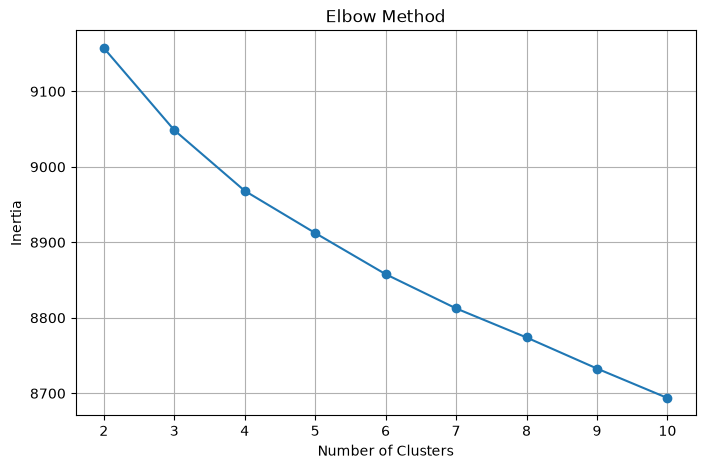

In [6]:
# ============================================================
# Elbow Curve
# ============================================================

plt.figure(figsize=(8, 5))

plt.plot(
    K,
    inertia,
    marker="o"
)

plt.title("Elbow Method")

plt.xlabel("Number of Clusters")

plt.ylabel("Inertia")

plt.grid(True)

plt.show()

In [7]:
# ============================================================
# Train Final K-Means Model
# ============================================================

optimal_k = 5   # Change this if your elbow suggests another value

kmeans = KMeans(
    n_clusters=optimal_k,
    random_state=42,
    n_init=10
)

kmeans.fit(job_vectors_sample)

print("K-Means model trained successfully!")

K-Means model trained successfully!


In [8]:
# ============================================================
# Assign Cluster Labels
# ============================================================

sample_jobs = sample_jobs.copy()

sample_jobs["Cluster"] = kmeans.labels_

display(sample_jobs[
    [
        "title",
        "company",
        "Cluster"
    ]
].head())

,title,company,Cluster
124499,Scheduler - Transit and Rail,Mace,2
44892,Maintenance Mechanic,CAPTEK® Softgel International,4
95237,"Line Producer, CourtTV",The E.W. Scripps Company,4
124511,Digital Chief Compliance Officer,GE Vernova,2
136638,Culinary Internship - Three Leaf Catering (Tem...,University of Notre Dame,4


Cluster
0    1352
1    1388
2    2603
3    1078
4    3579
Name: count, dtype: int64

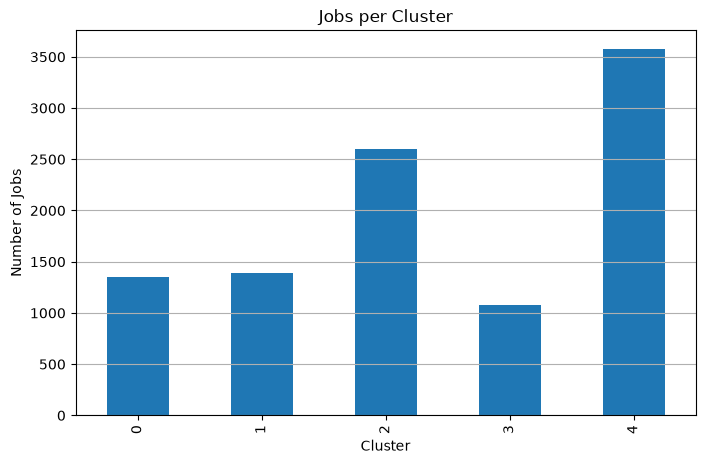

In [9]:
# ============================================================
# Cluster Distribution
# ============================================================

cluster_counts = sample_jobs["Cluster"].value_counts().sort_index()

display(cluster_counts)

plt.figure(figsize=(8,5))

cluster_counts.plot(kind="bar")

plt.title("Jobs per Cluster")

plt.xlabel("Cluster")

plt.ylabel("Number of Jobs")

plt.grid(axis="y")

plt.show()

In [10]:
# ============================================================
# Save K-Means Model
# ============================================================

MODEL_DIR = PROJECT_ROOT / "models"

MODEL_DIR.mkdir(exist_ok=True)

joblib.dump(
    kmeans,
    MODEL_DIR / "kmeans_model.pkl"
)

print("K-Means model saved successfully!")

K-Means model saved successfully!


In [11]:
# ============================================================
# Explore Cluster Contents
# ============================================================

for cluster in sorted(sample_jobs["Cluster"].unique()):

    print("=" * 60)
    print(f"Cluster {cluster}")
    print("=" * 60)

    display(
        sample_jobs[
            sample_jobs["Cluster"] == cluster
        ][
            [
                "title",
                "company"
            ]
        ].head(10)
    )

Cluster 0


,title,company
93833,New Home Sales Counselor,Landsea Homes
40608,Sales Manager,J. Galt
101130,Sales Associate Target Optical,Target Optical
105214,OPERATIONS ASSISTANT MANAGER,Dollar Tree Stores
90679,"Customer Service Representative, Full or Part ...",Circle K
105714,Retail Sales and Store Support,Tom Thumb Supermarket
25468,Store Manager,Pure Hockey
39668,Part Time Sales (16 and 17 Years Old),AutoZone
53067,Salesperson,Smith Imports LLC
97144,Auto Store Manager - Prenlyn Automotive Group,FirstChoice Hiring


Cluster 1


,title,company
328,After Market Sales Executives/auto/bearing/coc...,3D CONSULTANTS hiring for A leading and tradit...
12116,AssistantÂ Professor - Aerospace,Indian Institute of Technology Bombay
14875,Gm-quality Audit,TeamTeknik
4293,HR Internship,Danfoss Industries Pvt Ltd
5677,engineering manager,ValeurHR E-Solutions Pvt. Ltd.
15815,Java Developer,Avenues India Pvt. Ltd
17712,Visual Communication Lecturer,Educomp Raffles Higher Education Ltd
15902,Faculty (IELTS/GRE/GMAT),GEEBEE Education Pvt. Ltd.
15442,Opening in a Leading Big4_ VAPT,PRIME JOBS.IN
5519,Sr. iPhone Developer/Team Lead,The HRism


Cluster 2


,title,company
124499,Scheduler - Transit and Rail,Mace
124511,Digital Chief Compliance Officer,GE Vernova
52765,Project Engineer,"Wharton-Smith, Inc."
62253,"Senior Marketing Manager - Segment Lead, Third...",NYU Langone Health
78932,Cyber Threat Intelligence Technical Analyst,Bank of America
68435,DevOps Engineer,KonnectingTree Inc
34705,Global Senior Fit Tech - Men's Sportswear,Liberated Brands
77452,Corporate IT Systems Administrator,"Ahern Rentals, Inc."
51532,Static and Ground Loads-Loads and Dynamics Eng...,Honda Aircraft Company
84530,Contracts Manager,AECOM


Cluster 3


,title,company
96739,"Certified Nursing Assistant, Home Health Full ...",CenterWell Home Health
24803,Certified Nursing Assistant (CNA) Agency Free ...,Life Care Centers of America
63343,REGISTERED NURSE - **La Selva Residential**,Momentum for Health
67780,RN ICU,Southcoast Health
71456,Licensed Practical Nurse (LPN),A Hiring Company
134053,Physician Assistant - Hospital Medicine - Alto...,Vituity
76012,Transporter - Full Time - Days,UPMC
90554,Medical Technician,RWJBarnabas Health
91766,Sterile Processing Tech-PRN,Corpus Christi Medical Center
55796,Physician - Vascular Surgeon,CHRISTUS Health


Cluster 4


,title,company
44892,Maintenance Mechanic,CAPTEK® Softgel International
95237,"Line Producer, CourtTV",The E.W. Scripps Company
136638,Culinary Internship - Three Leaf Catering (Tem...,University of Notre Dame
34975,Customer Service Representative,Caliber Collision
61252,ISP Coordinator - Eyerly Ball,UnityPoint Health
113086,Regional Human Resources Generalist,Harbor Freight Tools
65166,Sr Workers Compensation Specialist,Schwan's Company
65454,US Experienced Financial Advisor,Edward Jones
114170,Warehouse Manager,Trillium Staffing Solutions
121994,"Maintenance Technician IV, 1st shift, Salt Lak...",New Balance


In [12]:
# ============================================================
# Top Terms per Cluster
# ============================================================

terms = tfidf.get_feature_names_out()

order_centroids = kmeans.cluster_centers_.argsort()[:, ::-1]

for i in range(optimal_k):

    print(f"\nCluster {i}")

    top_words = [
        terms[ind]
        for ind in order_centroids[i, :10]
    ]

    print(", ".join(top_words))


Cluster 0
sales, store, customer, customers, business, service, retail, work, team, manager

Cluster 1
doctorate, profile, software, specialization, description, programming, role, job, send, ppt

Cluster 2
project, experience, data, engineering, design, business, management, work, team, technical

Cluster 3
care, patient, health, patients, nursing, nurse, medical, rn, healthcare, clinical

Cluster 4
work, experience, team, service, job, ability, accounting, skills, required, management


# Conclusion

The job postings were successfully clustered using the K-Means algorithm.

### Results

- Sampled 10,000 job postings for efficient clustering.
- Converted job descriptions into TF-IDF vectors.
- Used the Elbow Method to determine an appropriate number of clusters.
- Trained a K-Means clustering model with 5 clusters.
- Assigned every sampled job to a cluster.
- Visualized the distribution of clusters.
- Saved the trained K-Means model for future use.

The clustering model can be used to organize job postings into related domains and enhance recommendation quality.